# Example prediction on a single test image

This notebook gives example code to make a single disparity prediction for one test image.

The file `test_simple.py` shows a more complete version of this code, which additionally:
- Can run on GPU or CPU (this notebook only runs on CPU)
- Can predict for a whole folder of images, not just a single image
- Saves predictions to `.npy` files and disparity images.

In [19]:
from __future__ import absolute_import, division, print_function
%matplotlib inline

import os
import numpy as np
import PIL.Image as pil
import matplotlib.pyplot as plt

import torch
from torchvision import transforms

import networks
from utils import download_model_if_doesnt_exist

## Setting up network and loading weights

In [20]:
model_name = "mono_640x192"

download_model_if_doesnt_exist(model_name)
encoder_path = os.path.join("models", model_name, "encoder.pth")
depth_decoder_path = os.path.join("models", model_name, "depth.pth")

# LOADING PRETRAINED MODEL
encoder = networks.ResnetEncoder(18, False)
depth_decoder = networks.DepthDecoder(num_ch_enc=encoder.num_ch_enc, scales=range(4))

loaded_dict_enc = torch.load(encoder_path, map_location='cpu')
filtered_dict_enc = {k: v for k, v in loaded_dict_enc.items() if k in encoder.state_dict()}
encoder.load_state_dict(filtered_dict_enc)

loaded_dict = torch.load(depth_decoder_path, map_location='cpu')
depth_decoder.load_state_dict(loaded_dict)

encoder.eval()
depth_decoder.eval();

## Loading the test image and preprocessing

In [25]:
imagePath="C:\\Users\\bsef0\\Downloads\\MonoDepth\\monodepth2-master\\Potholes - Copy\\1722600820.2793179_rgb.jpg"
image_path = image_path#"assets/test_image.jpg"

input_image = pil.open(image_path).convert('RGB')
original_width, original_height = input_image.size

feed_height = loaded_dict_enc['height']
feed_width = loaded_dict_enc['width']
input_image_resized = input_image.resize((feed_width, feed_height), pil.LANCZOS)

input_image_pytorch = transforms.ToTensor()(input_image_resized).unsqueeze(0)

## Prediction using the PyTorch model

In [26]:
with torch.no_grad():
    features = encoder(input_image_pytorch)
    outputs = depth_decoder(features)

disp = outputs[("disp", 0)]

## Plotting

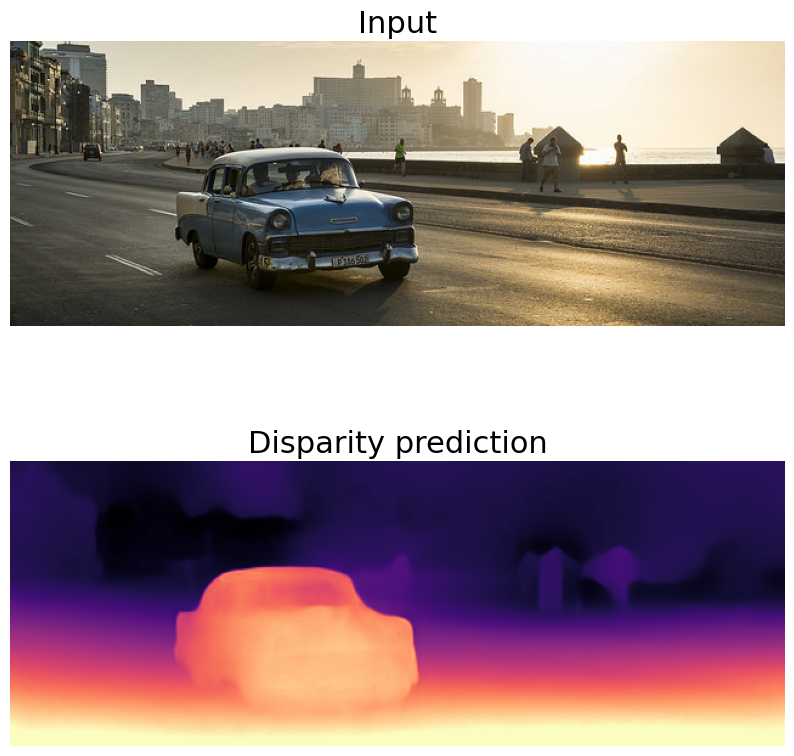

In [27]:
disp_resized = torch.nn.functional.interpolate(disp,
    (original_height, original_width), mode="bilinear", align_corners=False)

# Saving colormapped depth image
disp_resized_np = disp_resized.squeeze().cpu().numpy()
vmax = np.percentile(disp_resized_np, 95)

plt.figure(figsize=(10, 10))
plt.subplot(211)
plt.imshow(input_image)
plt.title("Input", fontsize=22)
plt.axis('off')

plt.subplot(212)
plt.imshow(disp_resized_np, cmap='magma', vmax=vmax)
plt.title("Disparity prediction", fontsize=22)
plt.axis('off');

In [29]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms
from PIL import Image
import cv2


In [30]:
model_name = "C:\\Users\\bsef0\\Downloads\\MonoDepth\\monodepth2-master\\monodepth2-master\\pothole_logs\\pothole\\models\\weights_18"

download_model_if_doesnt_exist(model_name)
encoder_path = os.path.join( model_name, "encoder.pth")
depth_decoder_path = os.path.join(model_name, "depth.pth")

# LOADING PRETRAINED MODEL
encoder = networks.ResnetEncoder(18, False)
depth_decoder = networks.DepthDecoder(num_ch_enc=encoder.num_ch_enc, scales=range(4))

loaded_dict_enc = torch.load(encoder_path, map_location='cpu')
filtered_dict_enc = {k: v for k, v in loaded_dict_enc.items() if k in encoder.state_dict()}
encoder.load_state_dict(filtered_dict_enc)

<All keys matched successfully>

In [32]:
from networks.depth_decoder import DepthDecoder
from networks.resnet_encoder import ResnetEncoder

def load_model(model_dir, device="cuda"):
    # encoder = ResnetEncoder(18, False)
    # depth_decoder = DepthDecoder(num_ch_enc=encoder.num_ch_enc)

    # Load model weights
    # encoder.load_state_dict(torch.load(encoder_path, map_location=device))
    # depth_decoder.load_state_dict(torch.load(depth_path, map_location=device))

    # encoder.eval()
    # depth_decoder.eval()

    # encoder.to(device)
    # depth_decoder.to(device)

    #return encoder, depth_decoder
    
    

    # Determine device
    device = torch.device(device if torch.cuda.is_available() else "cpu")

    # Initialize model dictionary
    model = {}

    # Load encoder
    encoder_path = f"{model_dir}/encoder.pth"
    encoder_dict = torch.load(encoder_path, map_location=device)
    encoder = ResnetEncoder(18, pretrained=False)  # Adjust num_layers if different
    encoder.load_state_dict(encoder_dict, strict=False)
    encoder.to(device)
    encoder.eval()
    model["encoder"] = encoder

    # Load depth decoder
    depth_path = f"{model_dir}/depth.pth"
    depth_dict = torch.load(depth_path, map_location=device)
    depth_decoder = DepthDecoder(encoder.num_ch_enc)
    depth_decoder.load_state_dict(depth_dict, strict=False)
    depth_decoder.to(device)
    depth_decoder.eval()
    model["depth"] = depth_decoder

    # Load pose encoder (if needed)
    pose_encoder = None
    pose_encoder_path = f"{model_dir}/pose_encoder.pth"
    try:
        pose_encoder_dict = torch.load(pose_encoder_path, map_location=device)
        pose_encoder = ResnetEncoder(18, pretrained=False, num_input_images=2)  # Adjust if needed
        pose_encoder.load_state_dict(pose_encoder_dict, strict=False)
        pose_encoder.to(device)
        pose_encoder.eval()
        model["pose_encoder"] = pose_encoder
    except FileNotFoundError:
        print("Pose encoder not found, skipping...")

    # Load pose decoder (if needed)
    pose_decoder = None
    pose_path = f"{model_dir}/pose.pth"
    try:
        pose_decoder_dict = torch.load(pose_path, map_location=device)
        pose_decoder = DepthDecoder(pose_encoder.num_ch_enc, num_output_channels=6)  # 6-DoF pose
        pose_decoder.load_state_dict(pose_decoder_dict, strict=False)
        pose_decoder.to(device)
        pose_decoder.eval()
        model["pose_decoder"] = pose_decoder
    except FileNotFoundError:
        print("Pose decoder not found, skipping...")

    # Load optimizer state (useful for resuming training)
    optimizer_state = None
    adam_path = f"{model_dir}/adam.pth"
    try:
        optimizer_state = torch.load(adam_path, map_location=device)
        model["optimizer_state"] = optimizer_state
    except FileNotFoundError:
        print("Optimizer state not found, skipping...")

    print("Model successfully loaded!")
    return model["encoder"],model["depth"]




In [33]:
def preprocess_image(img_path, height=240, width=320):
    input_image = Image.open(img_path).convert('RGB')
    original_size = input_image.size  # Save for resizing back if needed

    input_image = input_image.resize((width, height), Image.LANCZOS)
    input_tensor = transforms.ToTensor()(input_image).unsqueeze(0)
    return input_tensor, original_size, np.array(input_image)


In [34]:
def predict_depth(encoder, decoder, image_tensor, device):
    image_tensor = image_tensor.to(device)

    with torch.no_grad():
        features = encoder(image_tensor)
        outputs = decoder(features)

        disp = outputs[("disp", 0)]
        disp_resized = torch.nn.functional.interpolate(
            disp, (image_tensor.shape[2], image_tensor.shape[3]), mode="bilinear", align_corners=False
        )
        depth = 1 / disp_resized
        return depth.squeeze().cpu().numpy()


In [35]:
def show_image_and_depth(original_image, depth_map):
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.title("Input Image")
    plt.imshow(original_image)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Predicted Depth Map")
    plt.imshow(depth_map, cmap="plasma")
    plt.axis("off")

    plt.show()


In [36]:
def run_depth_demo(img_path, modelpath, device="cuda" if torch.cuda.is_available() else "cpu"):
    encoder, decoder = load_model(modelpath, device)
    image_tensor, _, original_image = preprocess_image(img_path)
    depth_map = predict_depth(encoder, decoder, image_tensor, device)
    show_image_and_depth(original_image, depth_map)

In [38]:

imagePath="C:\\Users\\bsef0\\Downloads\\MonoDepth\\monodepth2-master\\Potholes - Copy\\1722600820.2793179_rgb.jpg"
run_depth_demo(
        img_path=imagePath,
        modelpath="C:\\Users\\bsef0\\Downloads\\MonoDepth\\monodepth2-master\\monodepth2-master\\pothole_logs\\pothole\\models\\weights_18"
        
    )

Model successfully loaded!


RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 16 but got size 15 for tensor number 1 in the list.